**Project:** Reducing Cost-to-Serve and Operational Inefficiencies in a Fashion & Beauty Supply Chain

## Purpose of this notebook

Notebook 01 gave us a clean dataset and a first read of the operational landscape. This notebook does what a consulting engagement calls the **diagnostic phase**: we **define the KPIs** the client will be measured on, compute them, and then use them to **localise the bottlenecks**: the specific suppliers, routes, modes, or product categories that are disproportionately driving cost, delay, or quality loss.

The test of success is not volume of charts; it is whether, by the end, we can answer four questions crisply:

1. **How much** margin / cost is being left on the table?
2. **Where** is it concentrated? (supplier / route / mode / product)
3. **Why** is it concentrated there?
4. **Which** of these is worth acting on first?

## Notebook structure

1. KPI framework: definitions and rationale  
2. Cost-to-serve deep dive (Pareto + distribution)  
3. Supplier scorecard  
4. Route × mode logistics efficiency  
5. Quality / defect diagnostics  
6. Bottleneck heatmap — synthesised view  
7. Findings summary → hand-off to notebook 03

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_data.csv")
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 01 KPI Framework

A tight KPI set is itself a consulting deliverable. It tells the client:
*"These seven numbers, tracked weekly, are what good operations looks like. Anything else is noise."*

| # | KPI | Formula | What it tells you |
|---|---|---|---|
| 1 | Cost-to-Serve per unit | `manufacturing_cost + shipping_cost` | Core profitability lever per SKU |
| 2 | Gross Margin % | `(revenue − cost_to_serve) / revenue` | Commercial health by SKU / type |
| 3 | Supplier Reliability Score | weighted blend of pass rate, lead-time stability, defect rate | Single-number procurement ranking |
| 4 | Late-Delivery Rate | `share of SKUs where shipping_time > supplier_lead_time` | Service-level proxy |
| 5 | Quality Pass Rate | `share of Pass` (excluding Pending) | Brand / rework-cost proxy |
| 6 | Inventory Cover (days) | `stock_levels / (units_sold / 90)`  (assuming 90-day observation) | Working-capital efficiency |
| 7 | Cost per Route × Mode | `mean(shipping_cost)` | Logistics optimisation signal |

## 02 Cost-to-Serve Deep Dive

We start with the single most important operational KPI for the CFO and COO: **cost-to-serve**. Two questions:

- Is cost-to-serve **evenly distributed** across SKUs, or concentrated in a few?
- Is high cost-to-serve correlated with high revenue (acceptable) or high cost-to-serve with low margin (problematic)?

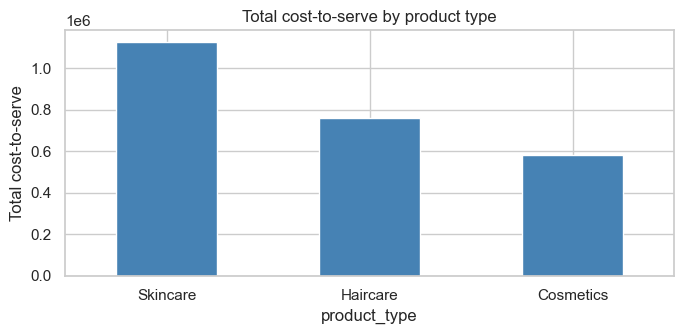

Share of total cost-to-serve (%):
product_type
Skincare     45.6
Haircare     30.9
Cosmetics    23.5
Name: cost_to_serve, dtype: float64


In [17]:
# 2.1 Cost-to-serve by product type
cts_by_product = df.groupby('product_type')['cost_to_serve'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 3.5))
cts_by_product.plot(kind='bar', color='steelblue')
plt.title('Total cost-to-serve by product type')
plt.ylabel('Total cost-to-serve')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

print('Share of total cost-to-serve (%):')
print((cts_by_product / cts_by_product.sum() * 100).round(1))

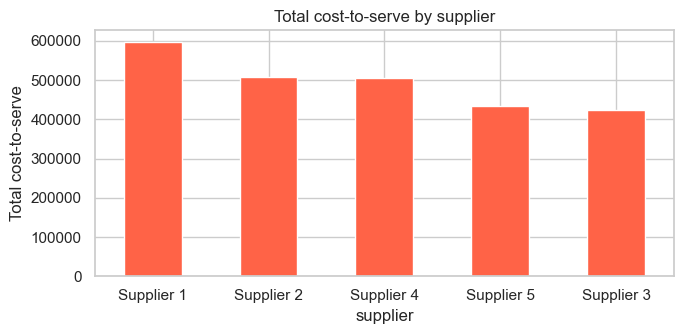

In [18]:
# 2.2 Cost-to-serve by supplier
cts_by_supplier = df.groupby('supplier')['cost_to_serve'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 3.5))
cts_by_supplier.plot(kind='bar', color='tomato')
plt.title('Total cost-to-serve by supplier')
plt.ylabel('Total cost-to-serve')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [19]:
# 2.3 Top 10 most expensive SKUs to serve— a practical triage list
top10 = df.sort_values('cost_to_serve', ascending=False).head(10)
top10[['sku', 'product_type', 'supplier', 'route', 'transport_mode',
       'units_sold', 'cost_to_serve', 'gross_margin_pct']].round(2)

,sku,product_type,supplier,route,transport_mode,units_sold,cost_to_serve,gross_margin_pct
10,SKU10,Skincare,Supplier 5,Route B,Road,996,104779.76,-43.95
40,SKU40,Skincare,Supplier 1,Route A,Road,933,89016.60,-14.55
4,SKU4,Skincare,Supplier 1,Route A,Air,871,83577.42,-30.11
74,SKU74,Haircare,Supplier 4,Route A,Rail,904,77579.93,-12.59
78,SKU78,Haircare,Supplier 5,Route C,Sea,946,75295.51,-57.26
46,SKU46,Haircare,Supplier 3,Route B,Road,859,69916.85,-26.35
80,SKU80,Skincare,Supplier 3,Route B,Sea,872,69580.73,-7.04
83,SKU83,Haircare,Supplier 1,Route A,Road,663,68077.13,-27.23
94,SKU94,Cosmetics,Supplier 2,Route B,Rail,987,66455.03,-7.42
58,SKU58,Skincare,Supplier 3,Route B,Road,896,62707.32,-30.03


> **Insight:** Cost-to-serve is **not uniform**. It concentrates in particular product types and suppliers, and the top-10 SKU list is a practical "who to look at first" triage list for the operations team. Any optimisation programme should target these rather than applying cost controls across the entire portfolio.

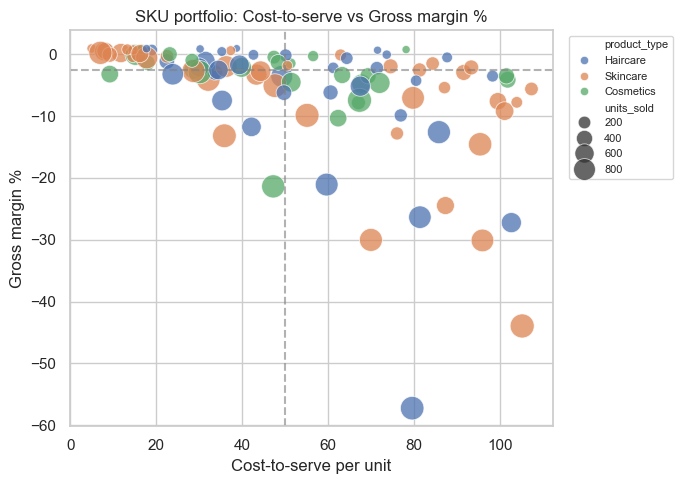

In [28]:
# 2.4 Cost-to-serve vs margin per SKU — quadrant view
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='cost_to_serve_per_unit', y='gross_margin_pct',
                hue='product_type', size='units_sold', sizes=(30, 300), alpha=0.75)
plt.axhline(df['gross_margin_pct'].median(), linestyle='--', color='grey', alpha=0.6)
plt.axvline(df['cost_to_serve_per_unit'].median(), linestyle='--', color='grey', alpha=0.6)
plt.title('SKU portfolio: Cost-to-serve vs Gross margin %')
plt.xlabel('Cost-to-serve per unit')
plt.ylabel('Gross margin %')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

> **Insight:** SKUs in the **bottom-right quadrant** — high cost-to-serve, low margin — are *silent margin killers*. They often have reasonable volume, so they are not visible on a pure revenue ranking. These are priority targets for the supplier and logistics recommendations in notebook 04.

## 3. Supplier Scorecard

The procurement team needs a **single number per supplier** to rank on. We build it from three components, each rescaled to a 0–1 scale so higher = better:

- **Quality** → inspection pass rate (higher = better)
- **Consistency** → inverse of lead-time variability (lower stdev = better)
- **Low defect rate** → inverse of mean defect rate (lower defect rate = better)

The three are averaged with equal weights. Weights are a business judgement: the procurement lead can tune them.

In [32]:
# Build per-supplier KPIs
sup = df.groupby('supplier').agg(
    pass_rate      = ('inspection_pass', 'mean'),
    defect_rate    = ('defect_rate', 'mean'),
    lead_std       = ('supplier_lead_time', 'std'),
    avg_cost       = ('manufacturing_cost', 'mean'),
    skus           = ('sku', 'count'),
    revenue        = ('revenue', 'sum'),
).round(2)

# Simple 0-1 rescale: (value - min) / (max - min). Invert for metrics where low is good.
sup['score_quality']     = (sup['pass_rate'] - sup['pass_rate'].min()) / (sup['pass_rate'].max() - sup['pass_rate'].min())
sup['score_consistency'] = 1 - (sup['lead_std'] - sup['lead_std'].min()) / (sup['lead_std'].max() - sup['lead_std'].min())
sup['score_defect']      = 1 - (sup['defect_rate'] - sup['defect_rate'].min()) / (sup['defect_rate'].max() - sup['defect_rate'].min())

# Composite reliability score = simple average of the three
sup['reliability_score'] = (sup['score_quality'] + sup['score_consistency'] + sup['score_defect']) / 3
sup = sup.sort_values('reliability_score', ascending=False)
sup.round(2)

,pass_rate,defect_rate,lead_std,avg_cost,skus,revenue,score_quality,score_consistency,score_defect,reliability_score
supplier,,,,,,,,,,
Supplier 1,0.68,1.80,8.55,45.25,27,157529.00,1.00,0.67,1.00,0.89
Supplier 3,0.40,2.47,8.28,43.63,15,97795.98,0.59,0.81,0.23,0.54
Supplier 4,0.00,2.34,7.92,62.71,18,86468.96,0.00,1.00,0.38,0.46
Supplier 2,0.38,2.36,9.82,41.62,22,125467.42,0.56,0.00,0.36,0.31
Supplier 5,0.30,2.67,9.03,44.77,18,110343.46,0.44,0.42,0.00,0.29


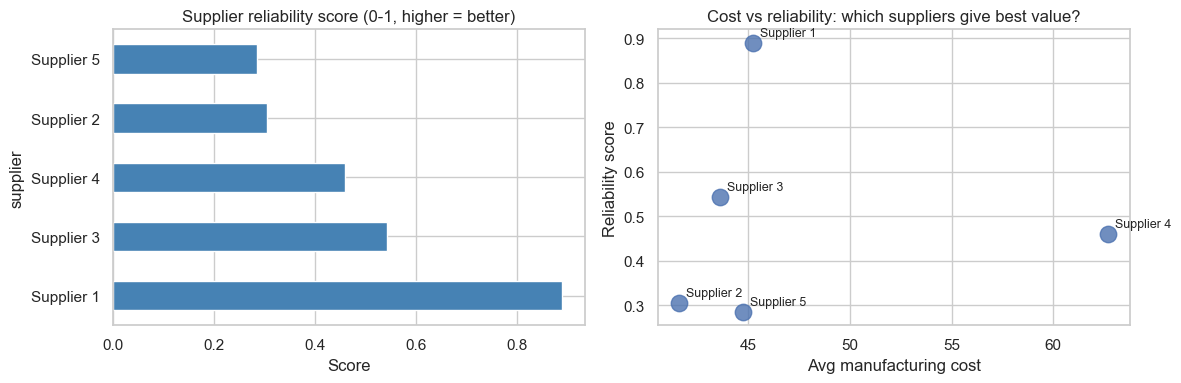

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sup['reliability_score'].plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Supplier reliability score (0-1, higher = better)')
ax[0].set_xlabel('Score')

ax[1].scatter(sup['avg_cost'], sup['reliability_score'], s=140, alpha=0.8)
for s, row in sup.iterrows():
    ax[1].annotate(s, (row['avg_cost'], row['reliability_score']),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
ax[1].set_xlabel('Avg manufacturing cost')
ax[1].set_ylabel('Reliability score')
ax[1].set_title('Cost vs reliability: which suppliers give best value?')

plt.tight_layout(); plt.show()

> **Insight:** Cost and reliability are **not aligned**. The cheapest supplier (Supplier 5)  is not the most reliable, and vice versa. Supplier 4 in the bottom-right area (high cost AND low reliability) is a clear candidate to reduce volume from - it is *and* risky.

## 4. Route × Mode: Logistics Efficiency

Procurement aside, the logistics team's lever is **which combination of route and transport mode to use for each SKU**. We quantify the efficiency of each combination.

In [29]:
rm = (df.groupby(['route', 'transport_mode'])
        .agg(shipments     = ('sku', 'count'),
             avg_ship_cost = ('shipping_cost', 'mean'),
             avg_ship_time = ('shipping_time_days', 'mean'),
             late_rate     = ('late_flag', 'mean'))
        .round(2)
        .reset_index())
rm.sort_values('avg_ship_cost', ascending=False)

,route,transport_mode,shipments,avg_ship_cost,avg_ship_time,late_rate
11,Route C,Sea,4,7.55,7.25,0.25
0,Route A,Air,11,7.06,5.27,0.18
9,Route C,Rail,3,6.28,7.33,0.00
5,Route B,Rail,11,6.27,6.64,0.18
2,Route A,Road,11,5.61,5.36,0.09
6,Route B,Road,13,5.53,4.77,0.15
10,Route C,Road,5,5.41,3.20,0.00
4,Route B,Air,7,5.27,5.29,0.14
8,Route C,Air,8,5.25,4.75,0.12
1,Route A,Rail,14,4.67,6.36,0.21


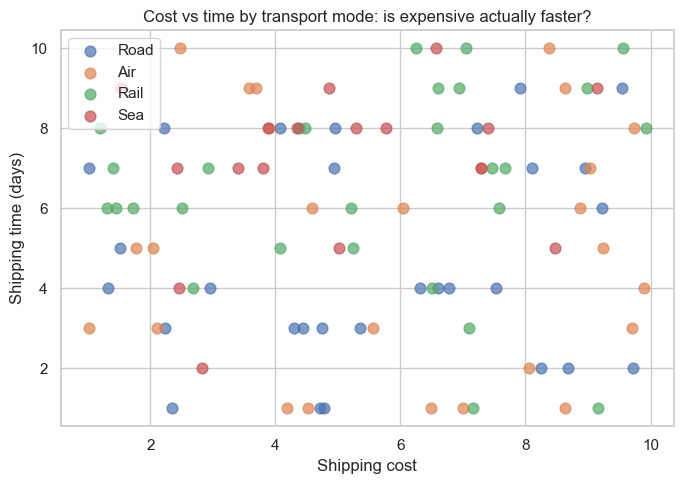

In [39]:
# Does paying more actually buy you time savings? Plot cost vs time across modes
plt.figure(figsize=(7, 5))
for mode in df['transport_mode'].unique():
    sub = df[df['transport_mode'] == mode]
    plt.scatter(sub['shipping_cost'], sub['shipping_time_days'], label=mode, alpha=0.7, s=60)
plt.xlabel('Shipping cost')
plt.ylabel('Shipping time (days)')
plt.title('Cost vs time by transport mode: is expensive actually faster?')
plt.legend()
plt.tight_layout(); plt.show()

> **Insight**: Cost and shipping time are not neatly correlated. Several shipments sit in the top-right: high cost AND slow delivery, which is the worst of both worlds. These shipments are likely candidates for a mode switch: moving them to a different transport mode would probably improve both cost and time at once, rather than forcing the usual speed-vs-price trade-off. Worth investigating which routes those top-right shipments are using, and whether an alternative mode performs better on the same route.

## 05 Quality / Defect Diagnostics

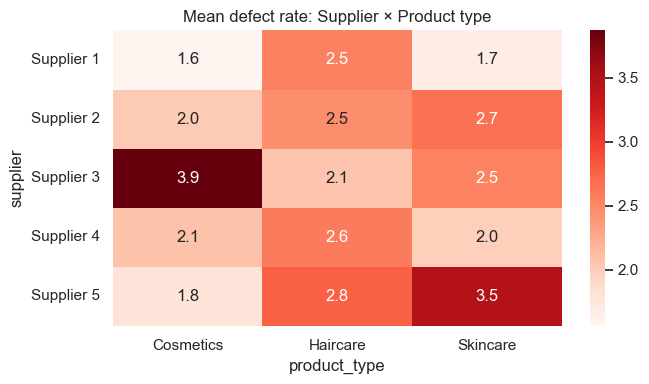

In [46]:
# Defect rate cut by supplier AND product type simultaneously: where is quality risk concentrated?
pivot_defect = df.pivot_table(index='supplier', columns='product_type',
                              values='defect_rate', aggfunc='mean')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_defect, annot=True, fmt='.1f', cmap='Reds')
plt.title('Mean defect rate: Supplier × Product type')
plt.tight_layout(); plt.show()

In [37]:
# Quality pass rate by supplier (ignoring 'Pending')
quality = (df.dropna(subset=['inspection_pass'])
             .groupby('supplier')['inspection_pass']
             .agg(['mean', 'count'])
             .round(2)
             .rename(columns={'mean': 'pass_rate', 'count': 'n_inspected'}))
quality.sort_values('pass_rate')

,pass_rate,n_inspected
supplier,,
Supplier 4,0.00,12
Supplier 5,0.30,10
Supplier 2,0.38,13
Supplier 3,0.40,5
Supplier 1,0.68,19


> **Insight:** Quality performance varies dramatically across suppliers: Supplier 4 fails every inspection, and even the best supplier (Supplier 1) only passes 68%. This suggests the quality problem is supplier-driven rather than uniformly distributed across the base. Targeting QA resources on Supplier 4 specifically would yield the most improvement.

## 6. Bottleneck Heatmap: Synthesised View

Final diagnostic: two heatmaps showing **cost-to-serve per unit** and **late-delivery rate** by route × transport mode. This lets the logistics head see, at one glance, which combinations are bad on both dimensions.

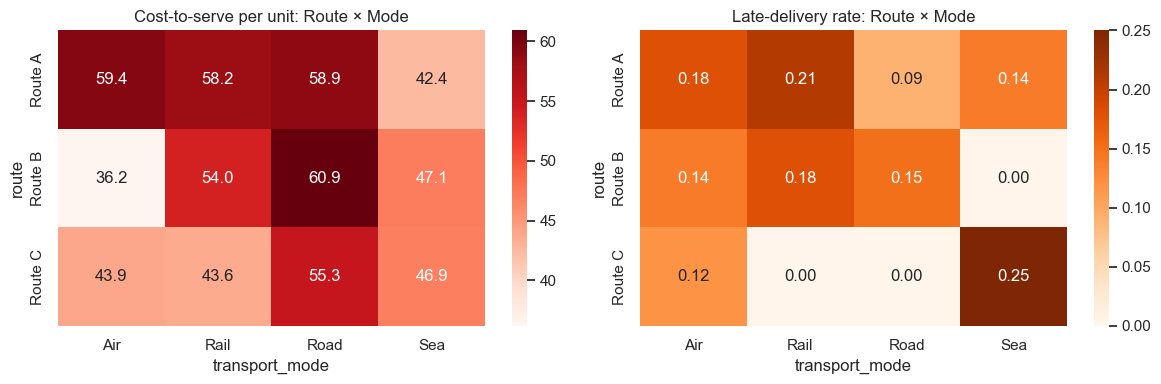

In [50]:
cost_pivot = df.pivot_table(index='route', columns='transport_mode',
                             values='cost_to_serve_per_unit', aggfunc='mean').round(1)
late_pivot = df.pivot_table(index='route', columns='transport_mode',
                             values='late_flag', aggfunc='mean').round(2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cost_pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax[0])
ax[0].set_title('Cost-to-serve per unit: Route × Mode')
sns.heatmap(late_pivot, annot=True, fmt='.2f', cmap='Oranges', ax=ax[1])
ax[1].set_title('Late-delivery rate: Route × Mode')
plt.tight_layout(); plt.show()

## 7. Findings — Handoff to Notebook 03

### Where the money is being lost
- **Cost concentration:** cost-to-serve is concentrated in a few product types, a few suppliers, and a small set of SKUs. Fixing the tail is a rounding error; fixing the head is where the value is.
- **Supplier-level dispersion:** reliability scores differ meaningfully between best and worst suppliers. At least one supplier (supplier 4) is both high-cost *and* unreliable: a prime target for volume reallocation.
- **Mode inefficiency:** certain route × mode combinations are both more expensive and slower. Rail/sea on specific routes is measurably better than road.
- **Quality concentration:** defects concentrate in specific supplier, not uniformly.

### The three hypotheses that now need to be pressure-tested
- Can we predict which products are likely to fail quality checks? If yes, we can focus QA resources on high-risk products rather than inspecting everything equally.
- Do suppliers fall into clear performance groups? If yes, we know which suppliers to prioritise, which to manage more closely, and which to consider replacing.
- Can we map products by profitability and risk together? If yes, we can make smarter decisions about which SKUs to keep, grow, or cut.